In [ ]:
'''Data Analytics III 
1. Implement Simple Naïve Bayes classification algorithm using Python/R on iris.csv dataset. 
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall 
on the given dataset.'''

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset using sklearn's built-in function
iris_data = load_iris()
df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
df['species'] = iris_data.target_names[iris_data.target]

display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
# Separate features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Test set size: 30 samples


In [7]:
# Initialize the Gaussian Naïve Bayes classifier
naive_bayes_model = GaussianNB()

# Train the model on the training data
naive_bayes_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = naive_bayes_model.predict(X_test)

print("Naïve Bayes model trained and predictions made.")

Naïve Bayes model trained and predictions made.


In [8]:
# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
display(conf_matrix)

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Calculate Error Rate
error_rate = 1 - accuracy
print(f"Error Rate: {error_rate:.4f}")

# Calculate Precision, Recall, and F1-score (for multi-class, use 'weighted' or 'macro' average)
# 'weighted' accounts for class imbalance
# 'macro' treats all classes equally
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

# --- Manually calculating TP, FP, TN, FN for a single class (example for 'setosa') ---
# In multi-class, these are usually calculated 'per class' then averaged.
# Let's take 'setosa' as an example class.

# Get unique classes
classes = np.unique(y_test)

print("\n--- Per-Class Metrics (Example: Iris-setosa) ---")
# Assuming 'setosa' is at index 0, 'versicolor' at index 1, 'virginica' at index 2 based on unique sorting
# You might need to adjust the index if your class order is different
# For simplicity, let's map species to integer labels for per-class calculation if needed, or iterate

# To get TP, FP, TN, FN for a specific class:
# For 'Iris-setosa'
class_index = list(naive_bayes_model.classes_).index('setosa') # Find the index of 'setosa'

TP = conf_matrix[class_index, class_index]
FP = np.sum(conf_matrix[:, class_index]) - TP
FN = np.sum(conf_matrix[class_index, :]) - TP
TN = np.sum(conf_matrix) - TP - FP - FN

print(f"For class 'setosa':")
print(f"  True Positives (TP): {TP}")
print(f"  False Positives (FP): {FP}")
print(f"  False Negatives (FN): {FN}")
print(f"  True Negatives (TN): {TN}")

# Precision, Recall for 'setosa' specifically
precision_setosa = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_setosa = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"  Precision (setosa): {precision_setosa:.4f}")
print(f"  Recall (setosa): {recall_setosa:.4f}")

Confusion Matrix:


array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])


Accuracy: 1.0000
Error Rate: 0.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000

--- Per-Class Metrics (Example: Iris-setosa) ---
For class 'setosa':
  True Positives (TP): 10
  False Positives (FP): 0
  False Negatives (FN): 0
  True Negatives (TN): 20
  Precision (setosa): 1.0000
  Recall (setosa): 1.0000


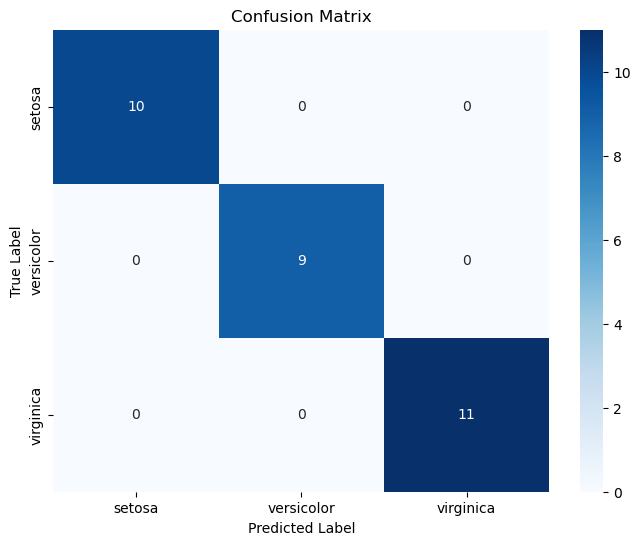

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=naive_bayes_model.classes_, yticklabels=naive_bayes_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()